<a href="https://colab.research.google.com/github/Mnu6/Ofiice_Public/blob/main/Commodity_Prophet_Forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Commodity Price Forecasting — Prophet Model
### Commodities: Aluminium, Copper, Lead, Nickel, Silver
### Forecast: 6 months ahead (Apr-2026 to Sep-2026)
### Model: Facebook Prophet — handles seasonality automatically

---
## HOW TO USE:
1. Run **Cell 1** — installs libraries
2. Run **Cell 2** — uploads your Excel file
3. Run **Cell 3** — checks your data
4. Run **Cell 4** — runs forecast for all commodities
5. Run **Cell 5** — shows charts
6. Run **Cell 6** — downloads Excel (Power BI ready)
---

In [3]:
# ══════════════════════════════════════════════════════
# CELL 1 — Install Libraries
# ══════════════════════════════════════════════════════
print('📦 Installing libraries...')
!pip install prophet pandas openpyxl matplotlib plotly -q
print('✅ All libraries installed!')

📦 Installing libraries...
✅ All libraries installed!


In [4]:
from google.colab import files
import pandas as pd
import io

print('📂 Please upload your Excel file...')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
print(f'✅ Uploaded: {filename}')

# Read ALL sheets at once
xl = pd.ExcelFile(io.BytesIO(uploaded[filename]))
print(f'\n📋 Sheets found: {xl.sheet_names}')

# Load each sheet
dfs = {}
for sheet in xl.sheet_names:
    dfs[sheet] = pd.read_excel(xl, sheet_name=sheet)
    print(f'  ✅ {sheet}: {len(dfs[sheet])} rows | Columns: {list(dfs[sheet].columns)}')

print('\n✅ All sheets loaded!')

📂 Please upload your Excel file...


Saving Commodity_WM.xlsx to Commodity_WM.xlsx
✅ Uploaded: Commodity_WM.xlsx

📋 Sheets found: ['USD_INR', 'Copper', 'Lead', 'AL', 'Ni', 'Silver ']
  ✅ USD_INR: 1355 rows | Columns: ['Date', 'Exch Rate ']
  ✅ Copper: 1311 rows | Columns: ['date', 'LME Copper USD/MT']
  ✅ Lead: 1311 rows | Columns: ['date', 'LME Lead USD/MT']
  ✅ AL: 1311 rows | Columns: ['date', 'LME Al USD/MT']
  ✅ Ni: 1311 rows | Columns: ['date', 'LME Nickel USD/MT']
  ✅ Silver : 1301 rows | Columns: ['date', 'Fine Silver USD/KG']

✅ All sheets loaded!


In [5]:
import pandas as pd
import numpy as np

# ── Column mapping based on your actual sheet names ───
COMMODITY_COLS = {
    'Aluminium' : ('AL',       'date', 'LME Al USD/MT',       'USD/MT'),
    'Copper'    : ('Copper',   'date', 'LME Copper USD/MT',   'USD/MT'),
    'Lead'      : ('Lead',     'date', 'LME Lead USD/MT',     'USD/MT'),
    'Nickel'    : ('Ni',       'date', 'LME Nickel USD/MT',   'USD/MT'),
    'Silver'    : ('Silver ',  'date', 'Fine Silver USD/KG',  'USD/KG'),
}

UNITS = {k: v[3] for k,v in COMMODITY_COLS.items()}

# ── Build master dataframe ─────────────────────────────
df_list = []
for comm, (sheet, date_col, val_col, unit) in COMMODITY_COLS.items():
    df_comm = dfs[sheet].copy()
    df_comm = df_comm.rename(columns={date_col:'Date', val_col:'Value'})
    df_comm['Date'] = pd.to_datetime(df_comm['Date'], dayfirst=True, errors='coerce')
    df_comm['Value'] = pd.to_numeric(
        df_comm['Value'].astype(str).str.replace(',','').str.strip(),
        errors='coerce'
    )
    df_comm = df_comm.dropna(subset=['Date','Value'])
    df_comm = df_comm.sort_values('Date').reset_index(drop=True)
    df_comm['Commodity'] = comm
    df_comm['Unit'] = unit
    df_list.append(df_comm)
    print(f'  ✅ {comm:12s} | Rows: {len(df_comm):4d} | '
          f'From: {df_comm["Date"].min().strftime("%d-%b-%Y")} | '
          f'Latest: {df_comm["Value"].iloc[-1]:.2f} {unit}')

df = pd.concat(df_list, ignore_index=True)

print(f'\n✅ MASTER DATA READY!')
print(f'   Total rows : {len(df):,}')
print(f'   Commodities: {df["Commodity"].unique().tolist()}')
print(f'   Date range : {df["Date"].min().strftime("%d-%b-%Y")} → {df["Date"].max().strftime("%d-%b-%Y")}')

  ✅ Aluminium    | Rows: 1311 | From: 04-Jan-2021 | Latest: 3467.00 USD/MT
  ✅ Copper       | Rows: 1311 | From: 04-Jan-2021 | Latest: 12850.50 USD/MT
  ✅ Lead         | Rows: 1311 | From: 04-Jan-2021 | Latest: 1886.00 USD/MT
  ✅ Nickel       | Rows: 1311 | From: 04-Jan-2021 | Latest: 17220.00 USD/MT
  ✅ Silver       | Rows: 1301 | From: 04-Jan-2021 | Latest: 2726.92 USD/KG

✅ MASTER DATA READY!
   Total rows : 6,545
   Commodities: ['Aluminium', 'Copper', 'Lead', 'Nickel', 'Silver']
   Date range : 04-Jan-2021 → 11-Mar-2026


In [6]:
from prophet import Prophet
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

FORECAST_MONTHS = 6
forecast_results = {}

print(f'🔄 Running Prophet forecast — {FORECAST_MONTHS} months ahead\n')

for comm in df['Commodity'].unique():
    print(f'  📊 Forecasting {comm}...')

    # Filter data for this commodity
    df_comm = df[df['Commodity'] == comm][['Date','Value']].dropna().copy()
    df_comm.columns = ['ds', 'y']
    df_comm['ds'] = pd.to_datetime(df_comm['ds'])

    # Prophet model
    model = Prophet(
        yearly_seasonality      = True,
        weekly_seasonality      = False,
        daily_seasonality       = False,
        seasonality_mode        = 'multiplicative',
        changepoint_prior_scale = 0.1,
        interval_width          = 0.95,
    )
    model.fit(df_comm)

    # Future dates — 6 months ahead
    future   = model.make_future_dataframe(periods=FORECAST_MONTHS*30, freq='D')
    forecast = model.predict(future)

    # Clean up
    forecast = forecast[['ds','yhat','yhat_lower','yhat_upper']].copy()
    forecast.columns = ['Date','Forecast','Lower_95','Upper_95']
    forecast['Forecast']  = forecast['Forecast'].round(2)
    forecast['Lower_95']  = forecast['Lower_95'].round(2)
    forecast['Upper_95']  = forecast['Upper_95'].round(2)
    forecast['Commodity'] = comm
    forecast['Unit']      = UNITS[comm]

    # Merge actuals
    actuals  = df_comm.rename(columns={'ds':'Date','y':'Actual'})
    forecast = forecast.merge(actuals, on='Date', how='left')

    # Flag type
    last_date = df_comm['ds'].max()
    forecast['Type'] = forecast['Date'].apply(
        lambda d: 'Actual' if d <= last_date else 'Forecast'
    )

    # Monthly — actual=last day, forecast=first day (no gap!)
    forecast['YearMonth'] = forecast['Date'].dt.to_period('M')
    actual_monthly = (
        forecast[forecast['Type']=='Actual']
        .groupby('YearMonth')
        .last()
        .reset_index(drop=True)
    )
    forecast_monthly_future = (
        forecast[forecast['Type']=='Forecast']
        .groupby('YearMonth')
        .first()
        .reset_index(drop=True)
    )
    forecast_monthly = pd.concat(
        [actual_monthly, forecast_monthly_future],
        ignore_index=True
    )

    forecast_results[comm] = forecast_monthly

    # Print forecast values
    future_only = forecast_monthly[forecast_monthly['Type']=='Forecast']
    print(f'    ✅ Done!')
    for _, row in future_only.iterrows():
        print(f'       {row["Date"].strftime("%b-%Y")} | '
              f'Forecast: {row["Forecast"]:>9.2f} | '
              f'Range: {row["Lower_95"]:.2f} – {row["Upper_95"]:.2f} {UNITS[comm]}')
    print()

print('✅ ALL FORECASTS COMPLETE!')

🔄 Running Prophet forecast — 6 months ahead

  📊 Forecasting Aluminium...
    ✅ Done!
       Mar-2026 | Forecast:   3222.39 | Range: 3050.64 – 3397.01 USD/MT
       Apr-2026 | Forecast:   3154.83 | Range: 2978.10 – 3331.20 USD/MT
       May-2026 | Forecast:   3101.35 | Range: 2891.87 – 3330.75 USD/MT
       Jun-2026 | Forecast:   3126.73 | Range: 2751.85 – 3499.78 USD/MT
       Jul-2026 | Forecast:   3050.57 | Range: 2522.99 – 3613.45 USD/MT
       Aug-2026 | Forecast:   3059.32 | Range: 2300.15 – 3803.16 USD/MT
       Sep-2026 | Forecast:   3158.80 | Range: 2130.75 – 4154.34 USD/MT

  📊 Forecasting Copper...
    ✅ Done!
       Mar-2026 | Forecast:  13314.29 | Range: 12770.25 – 13798.05 USD/MT
       Apr-2026 | Forecast:  13292.04 | Range: 12757.20 – 13872.36 USD/MT
       May-2026 | Forecast:  13288.73 | Range: 12476.98 – 14048.40 USD/MT
       Jun-2026 | Forecast:  13539.98 | Range: 12225.25 – 14931.94 USD/MT
       Jul-2026 | Forecast:  13163.32 | Range: 11177.92 – 15160.72 USD/MT
 

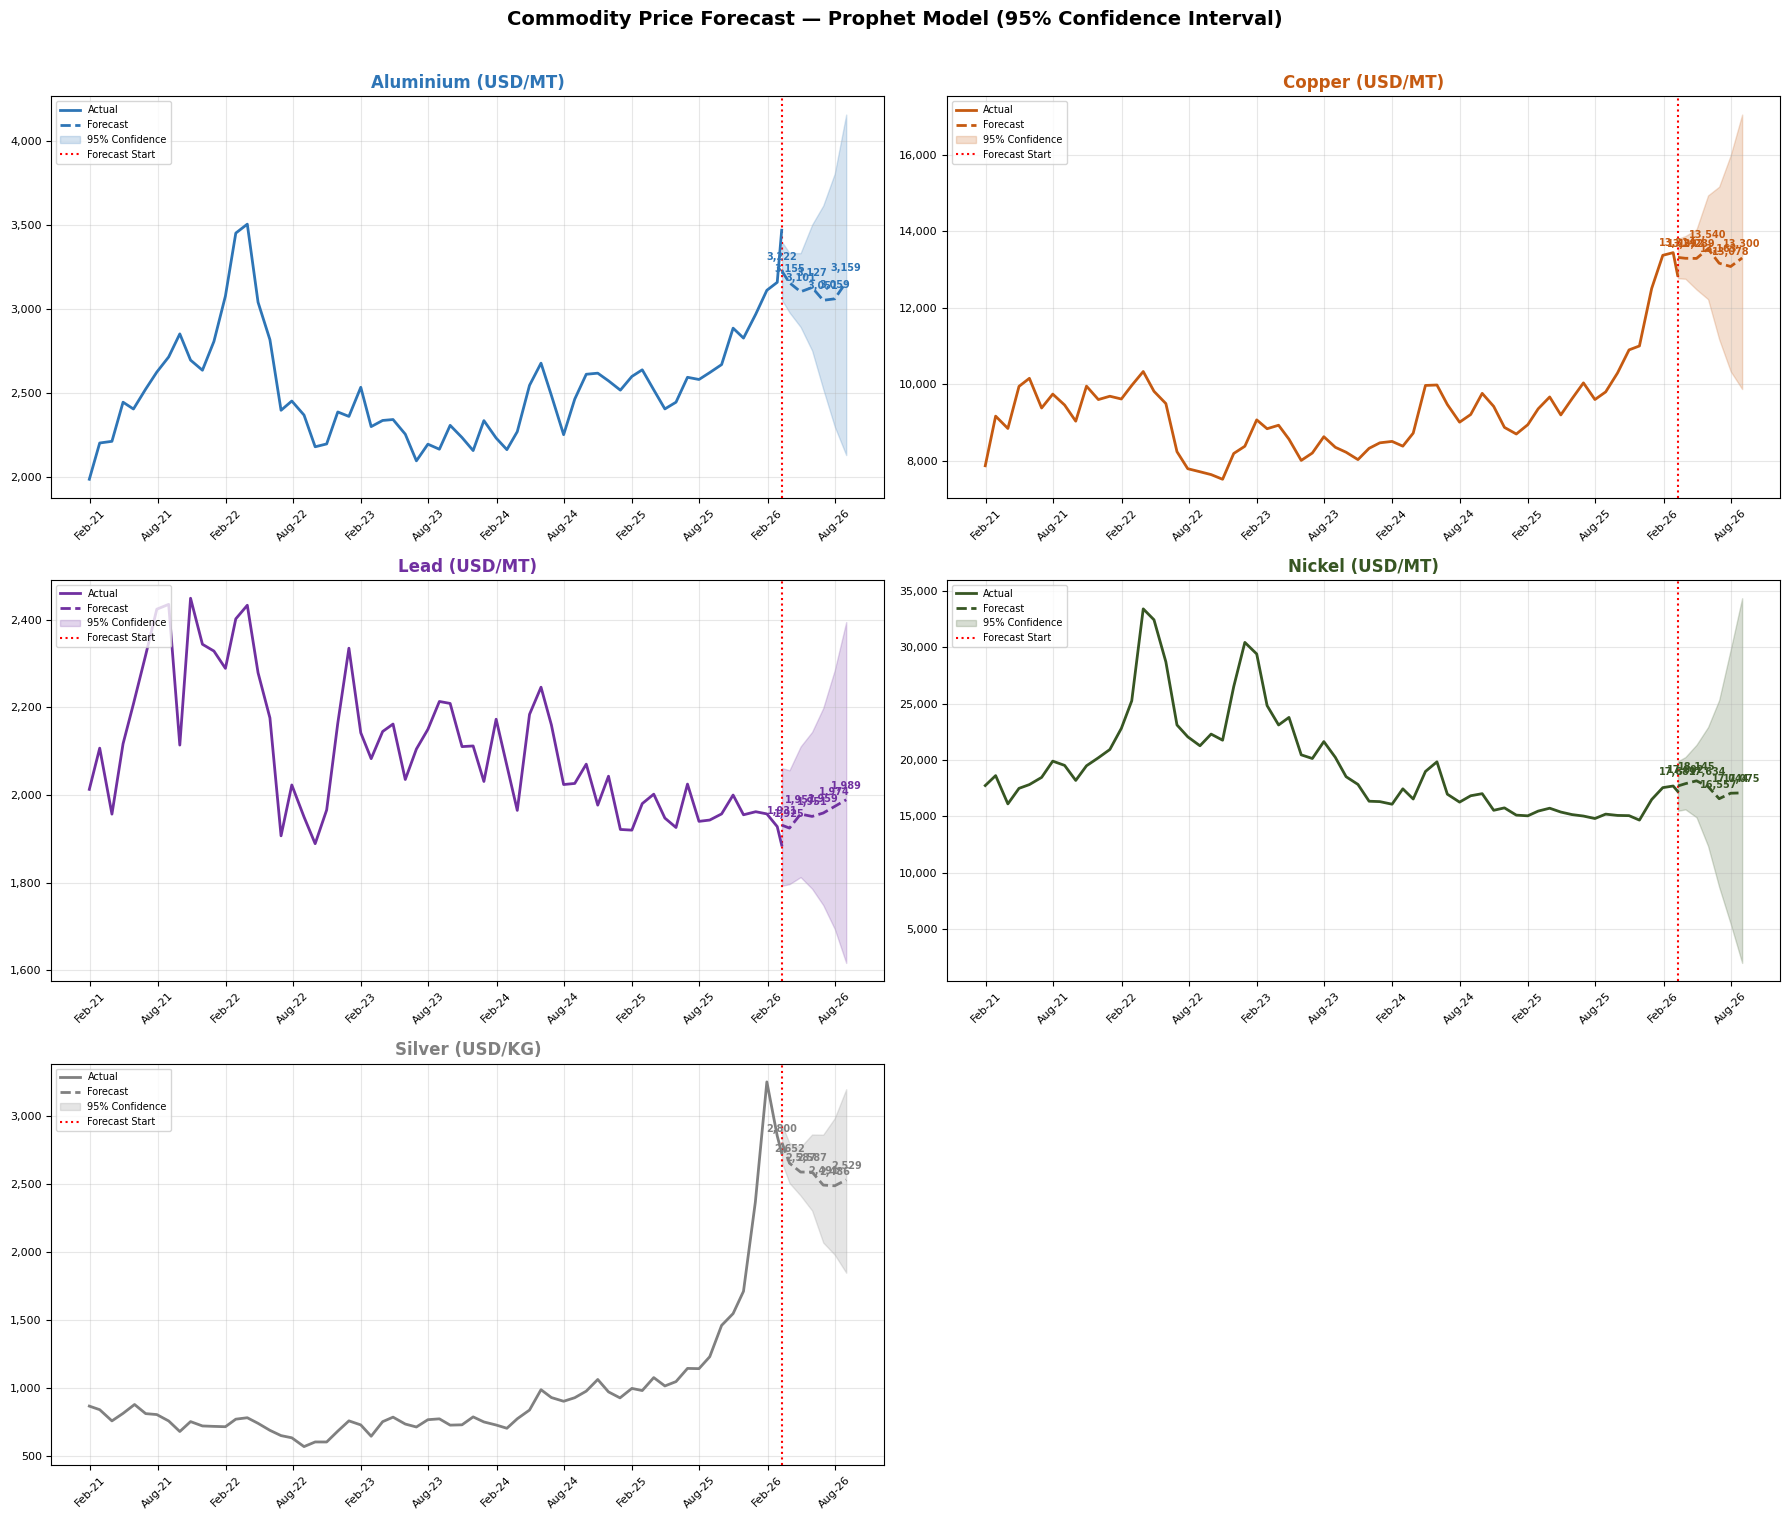

✅ Charts saved as Commodity_Forecast_Charts.png


In [7]:
# ══════════════════════════════════════════════════════
# CELL 5 — Plot Charts (one per commodity)
# Shows actual + forecast + confidence band
# ══════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 2, figsize=(18, 15))
fig.suptitle('Commodity Price Forecast — Prophet Model (95% Confidence Interval)',
             fontsize=14, fontweight='bold', y=1.01)

axes_flat = axes.flatten()
COLORS = {
    'Aluminium': '#2E75B6',
    'Copper'   : '#C55A11',
    'Lead'     : '#7030A0',
    'Nickel'   : '#375623',
    'Silver'   : '#808080',
}

for i, (comm, fc_df) in enumerate(forecast_results.items()):
    ax  = axes_flat[i]
    col = COLORS.get(comm, '#1F3864')

    actual   = fc_df[fc_df['Type'] == 'Actual']
    forecast = fc_df[fc_df['Type'] == 'Forecast']

    # Plot actual line
    ax.plot(actual['Date'], actual['Actual'],
            color=col, linewidth=2, label='Actual', zorder=3)

    # Plot forecast line (dashed)
    ax.plot(forecast['Date'], forecast['Forecast'],
            color=col, linewidth=2, linestyle='--',
            label='Forecast', zorder=3)

    # Confidence band (shaded area)
    ax.fill_between(
        forecast['Date'],
        forecast['Lower_95'],
        forecast['Upper_95'],
        alpha=0.2, color=col, label='95% Confidence'
    )

    # Add data labels on forecast points
    for _, row in forecast.iterrows():
        ax.annotate(
            f'{row["Forecast"]:,.0f}',
            xy=(row['Date'], row['Forecast']),
            xytext=(0, 8), textcoords='offset points',
            fontsize=7, ha='center', color=col, fontweight='bold'
        )

    # Vertical line at forecast start
    ax.axvline(x=pd.Timestamp('2026-03-11'),
               color='red', linestyle=':', linewidth=1.5,
               label='Forecast Start')

    # Formatting
    ax.set_title(f'{comm} ({UNITS[comm]})',
                 fontsize=12, fontweight='bold', color=col)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b-%y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=7, loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,p: f'{x:,.0f}'))

# Hide last empty subplot
axes_flat[5].set_visible(False)

plt.tight_layout()
plt.savefig('Commodity_Forecast_Charts.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Charts saved as Commodity_Forecast_Charts.png')

In [8]:
# ══════════════════════════════════════════════════════
# CELL 6 — Export to Excel (Power BI Ready)
# 3 sheets:
# 1. Master — all commodities long format (for Power BI)
# 2. Forecast Summary — wide format (for boss presentation)
# 3. Actuals + Forecast — combined per commodity
# ══════════════════════════════════════════════════════
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.styles.numbers import FORMAT_NUMBER_COMMA_SEPARATED1
import os

DARK_BLUE = '1F3864'; MID_BLUE = '2E75B6'; PALE_BLUE = 'DEEAF1'
WHITE = 'FFFFFF'; ORANGE = 'C55A11'; GREEN = 'E2EFDA'; YELLOW = 'FFF2CC'
COMM_COLORS = {
    'Aluminium':'CFE2F3','Copper':'FCE4D6','Lead':'E2EFDA',
    'Nickel':'F4CCCC','Silver':'EDEDED'
}

def mfill(c): return PatternFill('solid', fgColor=c)
def mfont(bold=False,color='000000',sz=9): return Font(name='Arial',bold=bold,color=color,size=sz)
def thin(): s=Side(style='thin',color='BFBFBF'); return Border(left=s,right=s,top=s,bottom=s)
def med():  s=Side(style='medium',color=MID_BLUE); return Border(left=s,right=s,top=s,bottom=s)
def ctr():  return Alignment(horizontal='center',vertical='center')

wb = Workbook()

# ══════════════════════════════════════════════════
# SHEET 1: MASTER (Power BI ready — long format)
# ══════════════════════════════════════════════════
ws1 = wb.active
ws1.title = '📊 MASTER (Power BI)'
ws1.sheet_view.showGridLines = False
ws1.freeze_panes = 'A3'

COLS1 = [
    ('Date',12,'DD-MM-YYYY'),
    ('Commodity',14,'@'),
    ('Unit',12,'@'),
    ('Type',10,'@'),
    ('Actual',14,'#,##0.00'),
    ('Forecast',14,'#,##0.00'),
    ('Lower_95',14,'#,##0.00'),
    ('Upper_95',14,'#,##0.00'),
    ('Month',12,'@'),
    ('Year',8,'0'),
]

# Title
ws1.merge_cells(f'A1:{get_column_letter(len(COLS1))}1')
t=ws1['A1']
t.value='COMMODITY PRICE DATA + PROPHET FORECAST | Jan-2021 to Sep-2026 | Power BI Ready'
t.font=Font(name='Arial',bold=True,size=11,color=WHITE)
t.fill=mfill(DARK_BLUE); t.alignment=ctr()
ws1.row_dimensions[1].height=26

# Headers
for ci,(cn,cw,fmt) in enumerate(COLS1,1):
    ws1.column_dimensions[get_column_letter(ci)].width=cw
    c=ws1.cell(row=2,column=ci,value=cn)
    c.font=Font(name='Arial',bold=True,color=WHITE,size=9)
    c.fill=mfill(MID_BLUE); c.alignment=ctr(); c.border=med()
ws1.row_dimensions[2].height=22

# Data
row_idx = 3
for comm, fc_df in forecast_results.items():
    bg = COMM_COLORS.get(comm, PALE_BLUE)
    for _, row in fc_df.iterrows():
        use_bg = bg if row['Type']=='Forecast' else WHITE
        vals = [
            row['Date'].date() if hasattr(row['Date'],'date') else row['Date'],
            comm,
            UNITS[comm],
            row['Type'],
            row['Actual'] if pd.notna(row.get('Actual')) else None,
            row['Forecast'],
            row['Lower_95'],
            row['Upper_95'],
            row['Date'].strftime('%b-%Y'),
            row['Date'].year,
        ]
        for ci,(val,(_,_,fmt)) in enumerate(zip(vals,COLS1),1):
            c=ws1.cell(row=row_idx,column=ci,value=val)
            c.font=mfont(bold=(row['Type']=='Forecast'))
            c.fill=mfill(use_bg); c.alignment=ctr(); c.border=thin()
            c.number_format=fmt
        row_idx+=1

print(f'  ✅ MASTER sheet: {row_idx-3:,} rows')

# ══════════════════════════════════════════════════
# SHEET 2: FORECAST SUMMARY (Boss presentation)
# ══════════════════════════════════════════════════
ws2 = wb.create_sheet('📋 FORECAST SUMMARY')
ws2.sheet_view.showGridLines = False

ws2.merge_cells('A1:H1')
ws2['A1'].value='COMMODITY PRICE FORECAST — Apr-2026 to Sep-2026 | Prophet Model | 95% Confidence Interval'
ws2['A1'].font=Font(name='Arial',bold=True,size=11,color=WHITE)
ws2['A1'].fill=mfill(DARK_BLUE); ws2['A1'].alignment=ctr()
ws2.row_dimensions[1].height=26

# Sub header
ws2.merge_cells('A2:H2')
ws2['A2'].value='Forecast Method: Facebook Prophet | Yearly seasonality | Multiplicative mode | Changepoint flexibility: 0.1'
ws2['A2'].font=Font(name='Arial',italic=True,size=9,color='595959')
ws2['A2'].alignment=ctr()
ws2.row_dimensions[2].height=18

hdrs2=['Month','Aluminium (USD/MT)','Copper (USD/MT)','Lead (USD/MT)','Nickel (USD/MT)','Silver (USD/KG)','Confidence Band','Notes']
wids2=[14,18,16,16,16,16,24,24]
for ci,(h,w) in enumerate(zip(hdrs2,wids2),1):
    c=ws2.cell(row=3,column=ci,value=h)
    c.font=Font(name='Arial',bold=True,color=WHITE,size=9)
    c.fill=mfill(MID_BLUE); c.alignment=ctr(); c.border=thin()
    ws2.column_dimensions[get_column_letter(ci)].width=w
ws2.row_dimensions[3].height=22

# Get forecast months only
forecast_months = {}
for comm, fc_df in forecast_results.items():
    fut = fc_df[fc_df['Type']=='Forecast'].copy()
    for _,row in fut.iterrows():
        month = row['Date'].strftime('%b-%Y')
        if month not in forecast_months:
            forecast_months[month] = {}
        forecast_months[month][comm] = {
            'forecast': row['Forecast'],
            'lower'   : row['Lower_95'],
            'upper'   : row['Upper_95'],
        }

ri=4
for month, comm_data in sorted(forecast_months.items(),
    key=lambda x: pd.to_datetime(x[0], format='%b-%Y')):
    bg = YELLOW
    row_vals = [month]
    band_parts = []
    for comm in ['Aluminium','Copper','Lead','Nickel','Silver']:
        if comm in comm_data:
            row_vals.append(comm_data[comm]['forecast'])
            band_parts.append(
                f"{comm[:2]}: {comm_data[comm]['lower']:,.0f}–{comm_data[comm]['upper']:,.0f}"
            )
        else:
            row_vals.append(None)
    row_vals.append(' | '.join(band_parts))
    row_vals.append('Prophet linear trend + seasonality')

    for ci,val in enumerate(row_vals,1):
        c=ws2.cell(row=ri,column=ci,value=val)
        c.font=mfont(bold=(ci==1))
        c.fill=mfill(bg if ri%2==0 else WHITE)
        c.alignment=ctr(); c.border=thin()
        if ci>1 and ci<7 and val: c.number_format='#,##0.00'
    ri+=1

print(f'  ✅ FORECAST SUMMARY sheet: {ri-4} forecast months')

# ══════════════════════════════════════════════════
# SHEET 3: ACTUALS + FORECAST combined (for charts)
# ══════════════════════════════════════════════════
ws3=wb.create_sheet('📈 ACTUALS + FORECAST')
ws3.sheet_view.showGridLines=False

ws3.merge_cells('A1:G1')
ws3['A1'].value='MONTHLY ACTUALS + FORECAST — All Commodities'
ws3['A1'].font=Font(name='Arial',bold=True,size=11,color=WHITE)
ws3['A1'].fill=mfill(DARK_BLUE); ws3['A1'].alignment=ctr()
ws3.row_dimensions[1].height=26

hdrs3=['Month','Aluminium','Copper','Lead','Nickel','Silver','Type']
for ci,h in enumerate(hdrs3,1):
    c=ws3.cell(row=2,column=ci,value=h)
    c.font=Font(name='Arial',bold=True,color=WHITE,size=9)
    c.fill=mfill(MID_BLUE); c.alignment=ctr(); c.border=thin()
    ws3.column_dimensions[get_column_letter(ci)].width=14

# Build combined monthly table
combined={}
for comm,fc_df in forecast_results.items():
    for _,row in fc_df.iterrows():
        month=row['Date'].strftime('%b-%Y')
        if month not in combined:
            combined[month]={'Type':row['Type']}
        val=row['Actual'] if row['Type']=='Actual' and pd.notna(row.get('Actual')) else row['Forecast']
        combined[month][comm]=round(float(val),2) if val else None

ri=3
for month,data in sorted(combined.items(),
    key=lambda x: pd.to_datetime(x[0],format='%b-%Y')):
    is_forecast = data.get('Type')=='Forecast'
    bg = YELLOW if is_forecast else (PALE_BLUE if ri%2==0 else WHITE)
    row_vals=[month,
              data.get('Aluminium'),data.get('Copper'),
              data.get('Lead'),data.get('Nickel'),data.get('Silver'),
              '🔮 Forecast' if is_forecast else '📊 Actual']
    for ci,val in enumerate(row_vals,1):
        c=ws3.cell(row=ri,column=ci,value=val)
        c.font=mfont(bold=is_forecast)
        c.fill=mfill(bg); c.alignment=ctr(); c.border=thin()
        if ci>1 and ci<7 and val: c.number_format='#,##0.00'
    ri+=1

print(f'  ✅ ACTUALS + FORECAST sheet: {ri-3} months total')

# Save
from datetime import datetime
fname=f'Commodity_Forecast_{datetime.today().strftime("%d%b%Y")}.xlsx'
wb.save(fname)
print(f'\n✅ Excel saved: {fname} ({os.path.getsize(fname)/1024:.0f} KB)')
print('   Sheets:')
print('   📊 MASTER (Power BI) — load this into Power BI')
print('   📋 FORECAST SUMMARY  — show this to boss')
print('   📈 ACTUALS + FORECAST — for charts')

  ✅ MASTER sheet: 350 rows
  ✅ FORECAST SUMMARY sheet: 7 forecast months
  ✅ ACTUALS + FORECAST sheet: 69 months total

✅ Excel saved: Commodity_Forecast_12Mar2026.xlsx (32 KB)
   Sheets:
   📊 MASTER (Power BI) — load this into Power BI
   📋 FORECAST SUMMARY  — show this to boss
   📈 ACTUALS + FORECAST — for charts


In [9]:
# ══════════════════════════════════════════════════════
# CELL 7 — Download Everything
# ══════════════════════════════════════════════════════
from google.colab import files

print('⬇️  Downloading Excel...')
files.download(fname)

print('⬇️  Downloading Charts PNG...')
files.download('Commodity_Forecast_Charts.png')

print()
print('🎉 DONE! You have:')
print(f'   📊 {fname}')
print('   📈 Commodity_Forecast_Charts.png')
print()
print('📌 HOW TO USE IN POWER BI:')
print('   1. Get Data → Excel → select the downloaded file')
print('   2. Load sheet: 📊 MASTER (Power BI)')
print('   3. In this table:')
print('      - Type = "Actual" → historical prices')
print('      - Type = "Forecast" → Prophet forecast')
print('      - Lower_95 / Upper_95 → confidence bands')
print('   4. Create measure: Actual Price = CALCULATE([Avg Price], MASTER[Type]="Actual")')
print('   5. Create measure: Forecast Price = CALCULATE(AVERAGE(MASTER[Forecast]), MASTER[Type]="Forecast")')
print('   6. Plot both on same line chart → solid + dashed lines!')

⬇️  Downloading Excel...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading Charts PNG...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 DONE! You have:
   📊 Commodity_Forecast_12Mar2026.xlsx
   📈 Commodity_Forecast_Charts.png

📌 HOW TO USE IN POWER BI:
   1. Get Data → Excel → select the downloaded file
   2. Load sheet: 📊 MASTER (Power BI)
   3. In this table:
      - Type = "Actual" → historical prices
      - Type = "Forecast" → Prophet forecast
      - Lower_95 / Upper_95 → confidence bands
   4. Create measure: Actual Price = CALCULATE([Avg Price], MASTER[Type]="Actual")
   5. Create measure: Forecast Price = CALCULATE(AVERAGE(MASTER[Forecast]), MASTER[Type]="Forecast")
   6. Plot both on same line chart → solid + dashed lines!
